# Predictive Modeling Study on New York Housing Rental Price

## VI. Prediction Model

 In the forecasting extension, we compare a naive baseline, ARIMA, and Exponential Smoothing using NYC average monthly ZORI rent. The **naive model** performs worst, with an MAE of about 123, because it does not adjust well to the recent high-rent period. **ARIMA** improves substantially, reducing MAE to about 37, showing that the **time-series structure** contains useful forecasting information. **Exponential Smoothing** performs best, with an MAE of about 23 and RMSE of about 29. This suggests that **NYC rent trends are smooth** and recent observations are especially informative for short-term forecasting.

In [ ]:
!pip install sktime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.8/160.8 kB 11.3 MB/s eta 0:00:00


In [ ]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 16.6 MB/s eta 0:00:00


### 1. Create a monthly time series

In [ ]:
# Create NYC-wide monthly average rent series
nyc_monthly = (
    zori_long
    .groupby("date")["zori_rent"]
    .mean()
    .reset_index()
    .sort_values("date")
)

nyc_monthly.head()

,date,zori_rent
0,2015-01-31,2659.788580
1,2015-02-28,2674.953349
2,2015-03-31,2672.698850
3,2015-04-30,2673.067202
4,2015-05-31,2659.813680


### 2. Convert to sktime format

In [ ]:
# Convert date column to monthly period index
y = nyc_monthly.set_index("date")["zori_rent"]

# Convert datetime index to monthly period index
y.index = y.index.to_period("M")

# Check the series
y.head()

,zori_rent
date,
2015-01,2659.788580
2015-02,2674.953349
2015-03,2672.698850
2015-04,2673.067202
2015-05,2659.813680


**Plot original series**

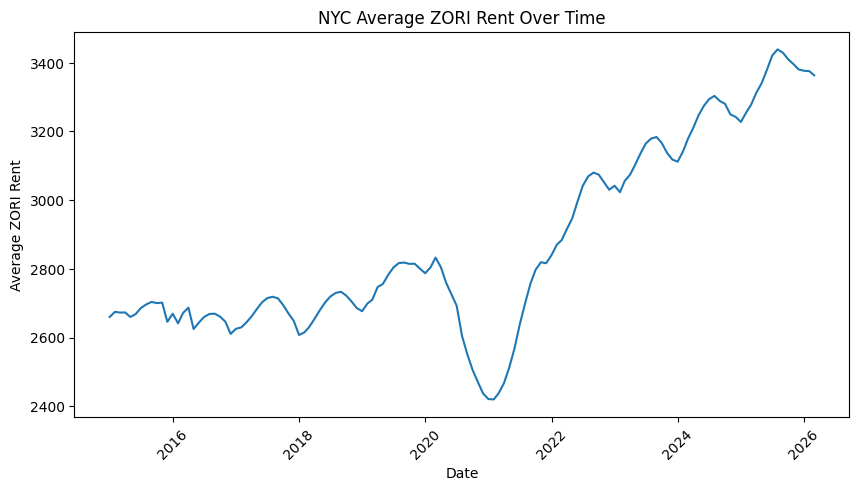

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(y.index.to_timestamp(), y.values)
plt.title("NYC Average ZORI Rent Over Time")
plt.xlabel("Date")
plt.ylabel("Average ZORI Rent")
plt.xticks(rotation=45)
plt.show()

### 4. Train-test split for forecasting

In [ ]:
from sktime.forecasting.model_selection import temporal_train_test_split

# Use last 12 months as test set
y_train, y_test = temporal_train_test_split(y, test_size=12)

print("Training period:", y_train.index.min(), "to", y_train.index.max())
print("Testing period:", y_test.index.min(), "to", y_test.index.max())

Training period: 2015-01 to 2025-03
Testing period: 2025-04 to 2026-03


### 5. Create forecasting horizon

In [ ]:
from sktime.forecasting.base import ForecastingHorizon

# Forecast the same dates as the test set
fh = ForecastingHorizon(y_test.index, is_relative=False)

fh

ForecastingHorizon(['2025-04', '2025-05', '2025-06', '2025-07', '2025-08', '2025-09',
             '2025-10', '2025-11', '2025-12', '2026-01', '2026-02', '2026-03'],
            dtype='period[M]', name='date', is_relative=False)

#### Model 1: Natice Forcasting Baseline

The Naive Forecast is much **less accurate** because it mostly repeats past patterns and **does not adjust well to the recent rent level**. In the plots, the naive line stays too low compared with the actual test rent.

In [ ]:
from sktime.forecasting.naive import NaiveForecaster

# Seasonal naive model: predicts using the same month from last year
naive_forecaster = NaiveForecaster(strategy="last", sp=12)

naive_forecaster.fit(y_train)

y_pred_naive = naive_forecaster.predict(fh)

y_pred_naive.head()

,zori_rent
date,
2025-04,3210.977307
2025-05,3246.808609
2025-06,3274.488238
2025-07,3293.777700
2025-08,3303.153046


**Evaluate**

In [ ]:
from sktime.performance_metrics.forecasting import mean_absolute_error, mean_squared_error
import numpy as np

naive_mae = mean_absolute_error(y_test, y_pred_naive)
naive_rmse = np.sqrt(mean_squared_error(y_test, y_pred_naive))

print("Naive Forecast MAE:", naive_mae)
print("Naive Forecast RMSE:", naive_rmse)

Naive Forecast MAE: 122.61510947030725
Naive Forecast RMSE: 124.307401318946


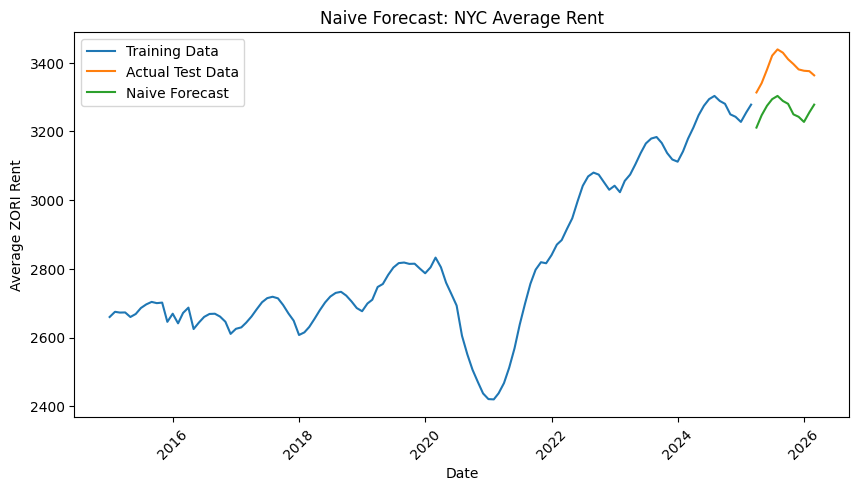

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(y_train.index.to_timestamp(), y_train.values, label="Training Data")
plt.plot(y_test.index.to_timestamp(), y_test.values, label="Actual Test Data")
plt.plot(y_pred_naive.index.to_timestamp(), y_pred_naive.values, label="Naive Forecast")

plt.title("Naive Forecast: NYC Average Rent")
plt.xlabel("Date")
plt.ylabel("Average ZORI Rent")
plt.legend()
plt.xticks(rotation=45)
plt.show()

#### Model 2: ARIMA Forcasting

ARIMA tracks the test period **much better**. It captures the general trend and **stays close to actual rent**, but it slightly **underpredicts some of the higher values**.

In [ ]:
from sktime.forecasting.arima import AutoARIMA

# AutoARIMA automatically searches for a good ARIMA specification
arima_forecaster = AutoARIMA(
    seasonal=True,
    sp=12,
    suppress_warnings=True
)

arima_forecaster.fit(y_train)

y_pred_arima = arima_forecaster.predict(fh)

y_pred_arima.head()

,zori_rent
date,
2025-04,3301.623988
2025-05,3327.543649
2025-06,3348.976733
2025-07,3363.929812
2025-08,3371.551979


In [ ]:
arima_mae = mean_absolute_error(y_test, y_pred_arima)
arima_rmse = np.sqrt(mean_squared_error(y_test, y_pred_arima))

print("ARIMA Forecast MAE:", arima_mae)
print("ARIMA Forecast RMSE:", arima_rmse)

ARIMA Forecast MAE: 36.59182564584413
ARIMA Forecast RMSE: 40.66471273089448


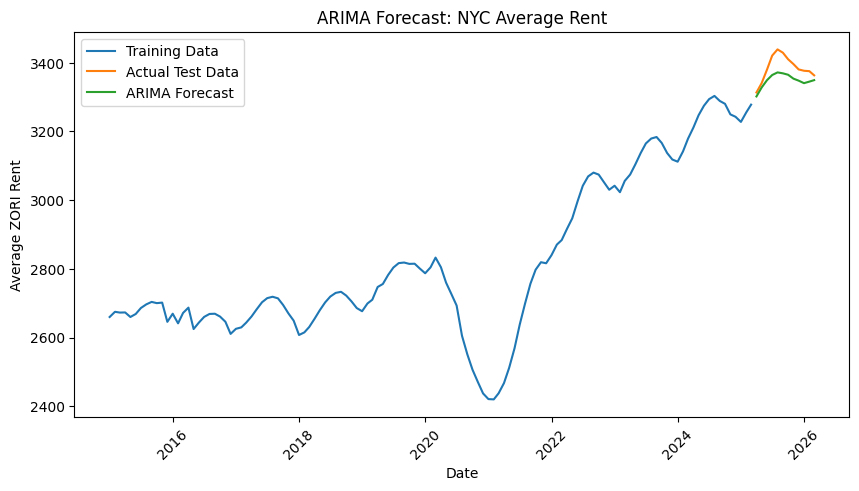

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(y_train.index.to_timestamp(), y_train.values, label="Training Data")
plt.plot(y_test.index.to_timestamp(), y_test.values, label="Actual Test Data")
plt.plot(y_pred_arima.index.to_timestamp(), y_pred_arima.values, label="ARIMA Forecast")

plt.title("ARIMA Forecast: NYC Average Rent")
plt.xlabel("Date")
plt.ylabel("Average ZORI Rent")
plt.legend()
plt.xticks(rotation=45)
plt.show()

### 6. Compare Naive vs ARIMA

In [ ]:
forecast_results = pd.DataFrame({
    "Model": ["Naive Forecast", "ARIMA"],
    "MAE": [naive_mae, arima_mae],
    "RMSE": [naive_rmse, arima_rmse]
})

forecast_results

,Model,MAE,RMSE
0,Naive Forecast,122.615109,124.307401
1,ARIMA,36.591826,40.664713


In this plot, the historical rent series shows a clear **COVID-era drop** around 2020–2021, **followed by a strong recovery and upward trend after 2021**. During the test period, ARIMA is much closer to actual rent than the naive forecast, while the naive forecast **consistently underpredicts**.

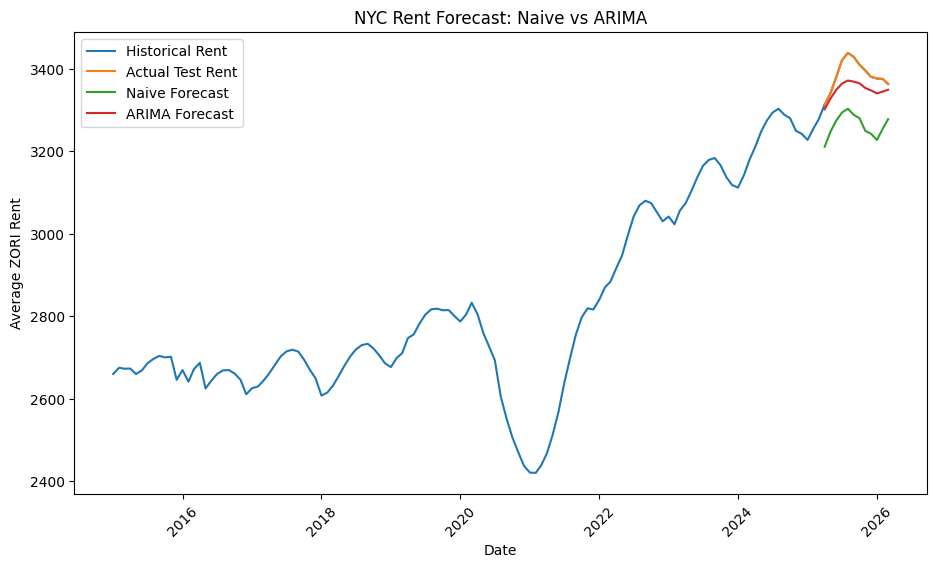

In [ ]:
plt.figure(figsize=(11, 6))

# Plot full historical series lightly
plt.plot(y.index.to_timestamp(), y.values, label="Historical Rent")

# Highlight test period
plt.plot(y_test.index.to_timestamp(), y_test.values, label="Actual Test Rent")

# Forecast lines
plt.plot(y_pred_naive.index.to_timestamp(), y_pred_naive.values, label="Naive Forecast")
plt.plot(y_pred_arima.index.to_timestamp(), y_pred_arima.values, label="ARIMA Forecast")

plt.title("NYC Rent Forecast: Naive vs ARIMA")
plt.xlabel("Date")
plt.ylabel("Average ZORI Rent")
plt.legend()
plt.xticks(rotation=45)
plt.show()

### 8. Forecast future 12 months

In the 12-month forecast plot, **ARIMA** predicts that NYC average rent will **remain high** **but relatively stable**, staying around the upper **$3,300 range** rather than continuing to rise sharply. This suggests the **model expects slower rent growth** after the recent post-pandemic increase.

In [ ]:
# Fit ARIMA on the full time series
final_arima = AutoARIMA(
    seasonal=True,
    sp=12,
    suppress_warnings=True
)

final_arima.fit(y)

# Forecast next 12 months
future_fh = list(range(1, 13))

future_pred = final_arima.predict(future_fh)

future_pred

,zori_rent
2026-04,3366.066462
2026-05,3374.329515
2026-06,3382.254711
2026-07,3386.783673
2026-08,3386.851287
2026-09,3383.059353
2026-10,3377.124147
2026-11,3371.150824
2026-12,3366.930087
2027-01,3365.447864


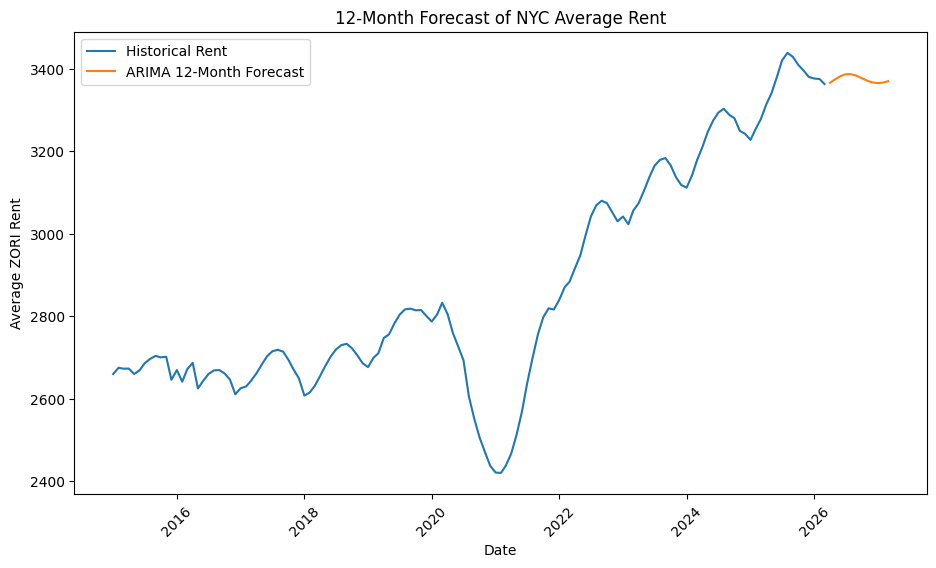

In [ ]:
plt.figure(figsize=(11, 6))

plt.plot(y.index.to_timestamp(), y.values, label="Historical Rent")
plt.plot(future_pred.index.to_timestamp(), future_pred.values, label="ARIMA 12-Month Forecast")

plt.title("12-Month Forecast of NYC Average Rent")
plt.xlabel("Date")
plt.ylabel("Average ZORI Rent")
plt.legend()
plt.xticks(rotation=45)
plt.show()

### 9. Smoothing

**Exponential Smoothing** performs best because NYC average rent changes smoothly over time, and this method gives more weight to recent observations. Since recent rent levels are highly informative, exponential smoothing **adapts better to the test period**.

In [ ]:
from sktime.forecasting.exp_smoothing import ExponentialSmoothing

exp_forecaster = ExponentialSmoothing(
    trend="add",
    seasonal="add",
    sp=12
)

exp_forecaster.fit(y_train)

y_pred_exp = exp_forecaster.predict(fh)

exp_mae = mean_absolute_error(y_test, y_pred_exp)
exp_rmse = np.sqrt(mean_squared_error(y_test, y_pred_exp))

print("Exponential Smoothing MAE:", exp_mae)
print("Exponential Smoothing RMSE:", exp_rmse)

Exponential Smoothing MAE: 22.944936684492216
Exponential Smoothing RMSE: 29.334595062565924


Exponential Smoothing performs best, ARIMA performs second best, and the Naive Forecast is the weakest baseline.

In [ ]:
forecast_results = pd.DataFrame({
    "Model": ["Naive Forecast", "ARIMA", "Exponential Smoothing"],
    "MAE": [naive_mae, arima_mae, exp_mae],
    "RMSE": [naive_rmse, arima_rmse, exp_rmse]
})

forecast_results

,Model,MAE,RMSE
0,Naive Forecast,122.615109,124.307401
1,ARIMA,36.591826,40.664713
2,Exponential Smoothing,22.944937,29.334595


In the test-period comparison plot, **Exponential Smoothing** follows the actual rent line **most closely**, especially around late 2025 and early 2026, while Naive Forecast stays too low and **ARIMA is moderately accurate** but smoother.

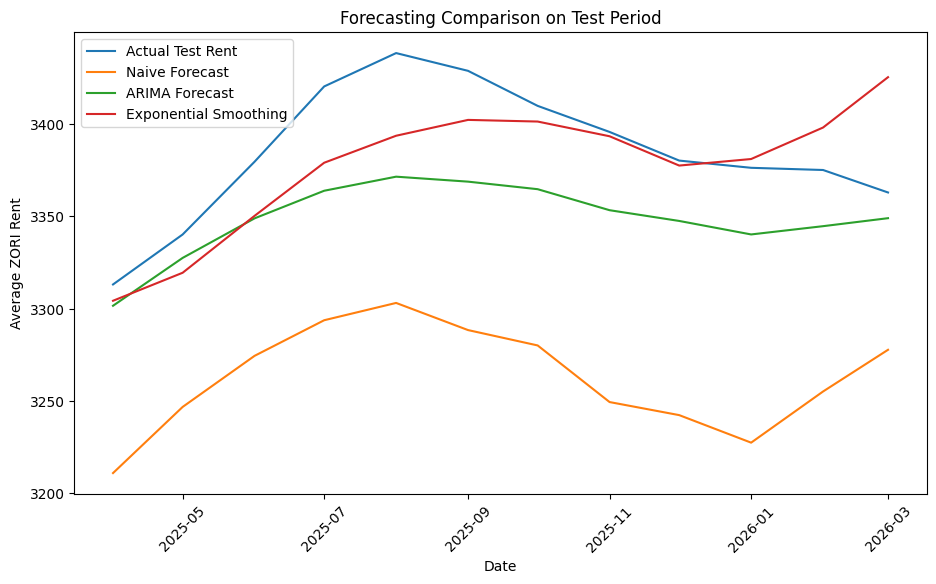

In [ ]:
plt.figure(figsize=(11, 6))

plt.plot(y_test.index.to_timestamp(), y_test.values, label="Actual Test Rent")
plt.plot(y_pred_naive.index.to_timestamp(), y_pred_naive.values, label="Naive Forecast")
plt.plot(y_pred_arima.index.to_timestamp(), y_pred_arima.values, label="ARIMA Forecast")
plt.plot(y_pred_exp.index.to_timestamp(), y_pred_exp.values, label="Exponential Smoothing")

plt.title("Forecasting Comparison on Test Period")
plt.xlabel("Date")
plt.ylabel("Average ZORI Rent")
plt.legend()
plt.xticks(rotation=45)
plt.show()

## VII. Conclusion

* Main finding:

  The **EDA** shows that NYC rent has **strong location differences** and clear **time-series patterns**. Consistent with this, **historical rent values** are the strongest predictors of future NYC rent. Because rent changes gradually over time, current and lagged rent variables are highly useful for prediction.


*   EDA finding:
  
    The EDA shows clear **spatial and temporal patterns** in NYC rent. **Manhattan** and **LIC** have much higher rent levels, while Queens, the Bronx, and Staten Island are more concentrated in lower rent ranges. Rent growth also shows a sharp COVID-era disruption followed by a strong rebound after 2021.
    

* Best regression model:

  **Linear Regression** performs best, with an MAE of about $34 and an R² of about 0.998. This suggests that next-month rent can be predicted very accurately using recent rent trends.

* Classification result:

  **Logistic Regression** performs better than KNN Classification for predicting whether a ZIP-code-month will be high-rent, with an accuracy of about 96.8%.

* Forecasting result:

  **Exponential Smoothing** performs best among the time-series models, outperforming both ARIMA and the naive baseline. This shows that recent rent observations are especially important for short-term forecasting.

* Limitations:

  **ZORI is an aggregated rent index, not individual apartment listing data**, so the model cannot capture apartment-level features such as bedrooms, amenities, building quality, or exact address.

* Next steps:

  Future work could **add subway access, income data, new housing supply, or individual rental listing data** to better explain neighborhood-level rent differences.